In [39]:
import pandas as pd
from IPython.display import display, Markdown
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import dash
from dash import html, dcc
from dash.dependencies import Output, Input, State
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier


df_original = pd.read_csv("data/commercial_planning.csv", encoding="latin-1")

display(Markdown("### Estructura y consistencia de los datos"))
info_df = pd.DataFrame({
    "Tipo de dato": df_original.dtypes,
    "Registros no nulos": df_original.notnull().sum(),
    "Valores faltantes (%)": (df_original.isnull().sum() / len(df_original) * 100).round(2)
})
display(info_df)

display(Markdown("-" * 70))

final_states = ["CLOSED", "COMPLETE", "CANCELED", "SUSPECTED_FRAUD"]
df_original = df_original[df_original["Order Status"].isin(final_states)]
df_original["Order Success"] = df_original["Order Status"].isin(["COMPLETE", "CLOSED"]).astype(int)

display(Markdown(f"#### Variable 'Order Status': {df_original["Order Status"].unique()} ---> Variable Target 'Order Success': {df_original["Order Success"].unique()}"))

### Estructura y consistencia de los datos

,Tipo de dato,Registros no nulos,Valores faltantes (%)
Days for shipment (scheduled),int64,180519,0.0
Category Name,object,180519,0.0
Market,object,180519,0.0
Order Item Discount,float64,180519,0.0
Order Item Profit Ratio,float64,180519,0.0
Order Region,object,180519,0.0
Order Status,object,180519,0.0
Product Price,float64,180519,0.0
Shipping Mode,object,180519,0.0


----------------------------------------------------------------------

#### Variable 'Order Status': ['COMPLETE' 'CLOSED' 'CANCELED' 'SUSPECTED_FRAUD'] ---> Variable Target 'Order Success': [1 0]

### El 91.07% de las transacciones terminan en éxito ---> Target Desbalanceada

----------------------------------------------------------------------

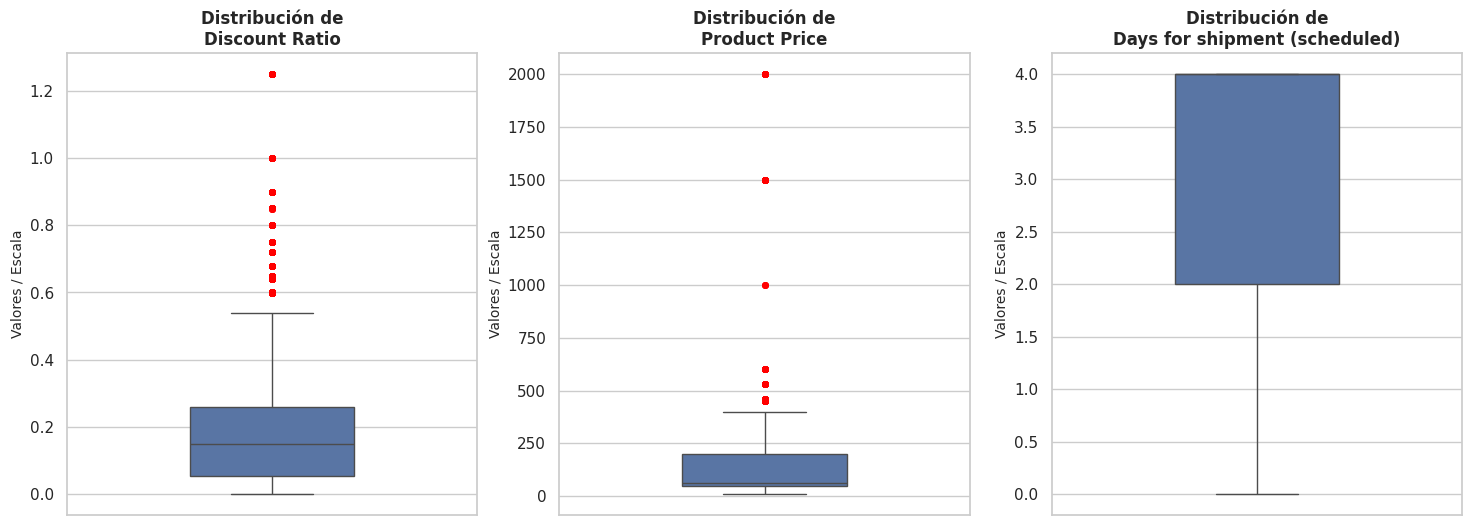

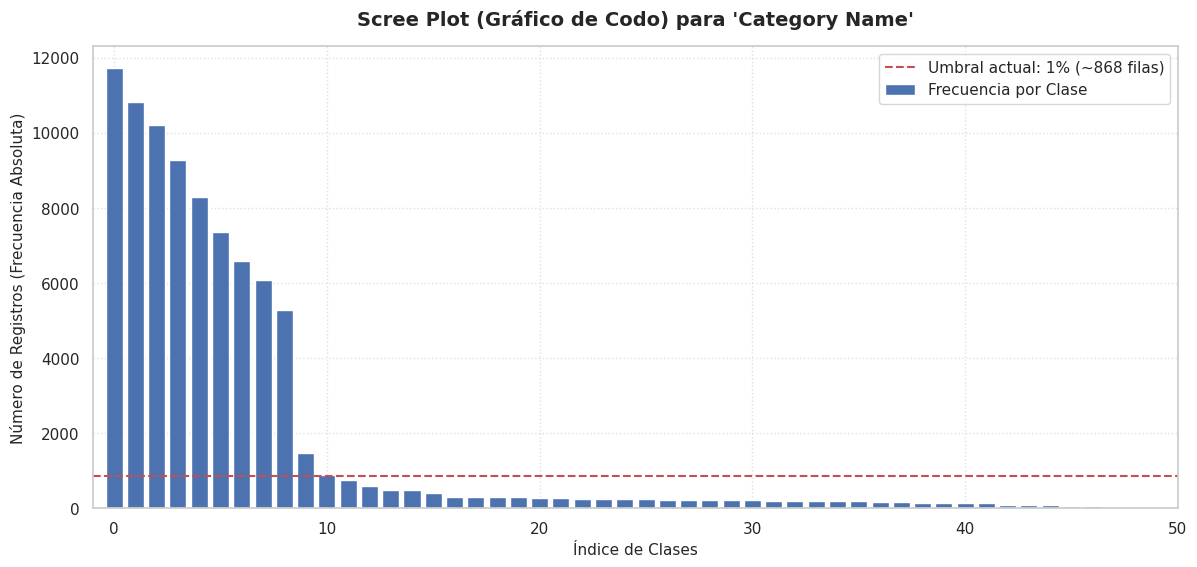

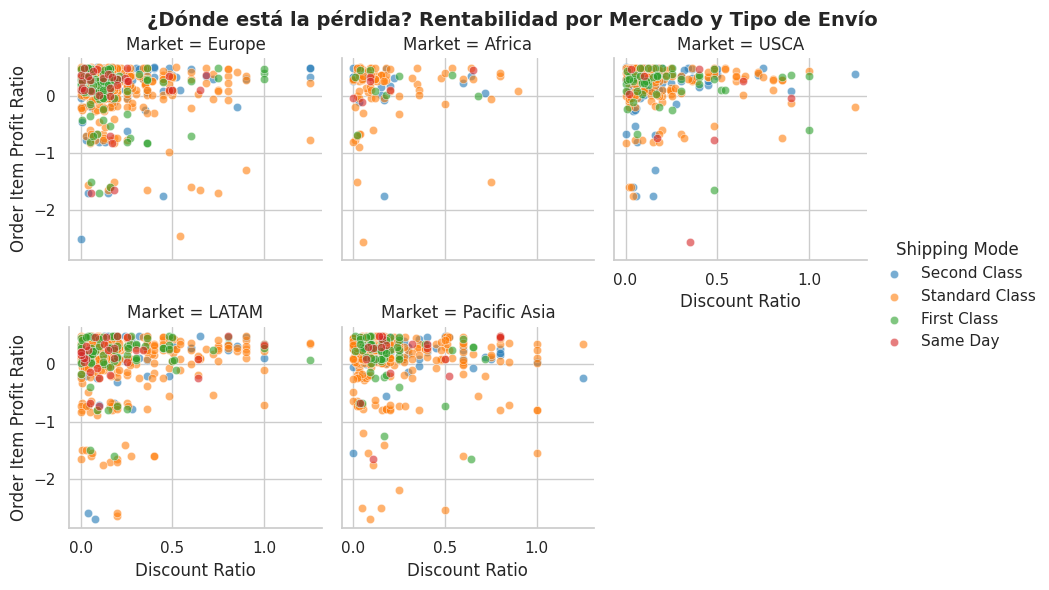

In [40]:
df_original["Discount Ratio"] = df_original["Order Item Discount"] / df_original["Product Price"]

success_counts = df_original["Order Success"].value_counts(normalize=True) * 100
display(Markdown(f"### El {success_counts[1]:.2f}% de las transacciones terminan en éxito ---> Target Desbalanceada"))
display(Markdown("-" * 70))

numeric_vars = ["Discount Ratio","Product Price","Days for shipment (scheduled)"]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
sns.set_theme(style="whitegrid")

for i, col in enumerate(numeric_vars):
    sns.boxplot(y=df_original[col], ax=axes[i], color="#4C72B0", width=0.4, flierprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "none", "markersize": 5})
    axes[i].set_title(f"Distribución de\n{col}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Valores / Escala", fontsize=10)
    axes[i].set_xlabel("")

plt.show()

counts = df_original["Category Name"].value_counts()
percentages = df_original["Category Name"].value_counts(normalize=True)

df_plot = pd.DataFrame({
    "Class": counts.index,
    "Frecuency": counts.values,
    "Percentage": percentages.values
}).reset_index(drop=True)

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")
plt.bar(df_plot.index, df_plot["Frecuency"], color="b", label="Frecuencia por Clase")

umbral = df_original.shape[0] * 0.01
plt.axhline(y=umbral, color="r", linestyle="--", linewidth=1.5, label=f"Umbral actual: 1% (~{int(umbral)} filas)")

plt.title("Scree Plot (Gráfico de Codo) para 'Category Name'", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Índice de Clases", fontsize=11)
plt.ylabel("Número de Registros (Frecuencia Absoluta)", fontsize=11)
plt.xlim(-1, len(df_plot))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')

grid = sns.FacetGrid(df_original.sample(min(2000, len(df_original))), col="Market", hue="Shipping Mode", palette="tab10", col_wrap=3)
grid.map(sns.scatterplot, "Discount Ratio", "Order Item Profit Ratio", alpha=0.6)
grid.add_legend()
grid.fig.subplots_adjust(top=0.9)
grid.fig.suptitle("¿Dónde está la pérdida? Rentabilidad por Mercado y Tipo de Envío", fontsize=14, fontweight="bold")
plt.show()

#### Feature Engineering: estandarización, numeralización y sobremuestreo
Este enfoque de preprocesamiento de variables se basa en el Análisis Exploratorio de Datos previo, diseñado para optimizar el rendimiento y la estabilidad del modelo al unificar la escala de los datos, estructurar variables cualitativas y balancear la representatividad de las clases. La combinación de estandarización sin valores Outliers, codificación Target con una reducción previa de multiclases y sobremuestreo previene el sesgo algorítmico, acelera la convergencia del entrenamiento y garantiza que las métricas de evaluación reflejen la capacidad real de generalización del modelo.


In [41]:
df = df_original.copy()
df.drop(columns=["Order Status","Order Item Discount"], inplace=True)
df = df.reset_index(drop=True)

Q1_discount_radio = df["Discount Ratio"].quantile(0.25)
Q3_discount_radio = df["Discount Ratio"].quantile(0.75)
IQR_discount_radio = Q3_discount_radio - Q1_discount_radio
df = df.loc[~((df["Discount Ratio"] < (Q1_discount_radio - 1.5 * IQR_discount_radio)) | (df["Discount Ratio"] > (Q3_discount_radio + 1.5 * IQR_discount_radio))),:]

Q1_product_price = df["Product Price"].quantile(0.25)
Q3_product_price = df["Product Price"].quantile(0.75)
IQR_product_price = Q3_product_price - Q1_product_price
df = df.loc[~((df["Product Price"] < (Q1_product_price - 1.5 * IQR_product_price)) | (df["Product Price"] > (Q3_product_price + 1.5 * IQR_product_price))),:]

categorical_vars = ["Category Name", "Market", "Order Region", "Shipping Mode"]
numeric_vars = ["Days for shipment (scheduled)", "Product Price", "Discount Ratio"]

X_train, X_test, y_train, y_test = train_test_split(df[categorical_vars + numeric_vars],
                                                    df["Order Success"],
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=df["Order Success"])

umbral = 0.01
categories_distribution = X_train["Category Name"].value_counts(normalize=True)
valid_categories = categories_distribution[categories_distribution > umbral].index

X_train["Category Name"] = X_train["Category Name"].where(X_train["Category Name"].isin(valid_categories), "OTHERS")
X_test["Category Name"] = X_test["Category Name"].where(X_test["Category Name"].isin(valid_categories), "OTHERS")

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_vars])
X_train_num = pd.DataFrame(X_train_num, columns=numeric_vars, index=X_train.index)

encoder = TargetEncoder(cols=categorical_vars)
X_train_cat = encoder.fit_transform(X_train[categorical_vars], y_train)

X_train_processed = pd.concat([X_train_cat, X_train_num], axis=1)

smote = SMOTE(sampling_strategy=0.25, random_state=42)
X_train_processed_balanced, y_train = smote.fit_resample(X_train_processed, y_train)

display(Markdown("### Dataframe procesado (análisis predictivo)"))
display(X_train_processed_balanced)

### Dataframe procesado (análisis predictivo)

,Category Name,Market,Order Region,Shipping Mode,Days for shipment (scheduled),Product Price,Discount Ratio
0,0.911488,0.914720,0.910937,0.911512,0.777652,1.310527,-0.748261
1,0.911871,0.913102,0.916127,0.911512,0.777652,-0.982677,1.808678
2,0.911157,0.906842,0.913813,0.903414,-1.400458,-0.690804,-0.557458
3,0.911396,0.913102,0.916127,0.911512,0.777652,2.144450,-0.748268
4,0.911396,0.906842,0.913813,0.903414,-1.400458,2.144450,-0.748268
...,...,...,...,...,...,...,...
70306,0.912439,0.911942,0.906121,0.911512,0.777652,-0.774280,2.723020
70307,0.910384,0.906842,0.901092,0.903414,-1.400458,-0.774113,-0.252392
70308,0.911157,0.908955,0.898928,0.916395,-0.674421,-0.690804,1.833741
70309,0.909509,0.913102,0.906509,0.911512,0.777652,-0.857589,-0.862650


#### Bagging (K-Neighbors): reforzando los casos más cercanos
Es una de las principales técnicas computacionales de estadística inferencial cuya objetivo se basa en eliminar o reducir lo máximo posible la varianza en los resultados, su método es utilizar la sabiduría de las masas, es decir, reforzar el aprendizaje mediante el criterio de distintos metaestimadores que se encargarán de sacar sus propias conclusiones de respectivos datos seleccionados para luego, dependiendo del problema en cuestión, llegar a una respuesta final a través de la media o moda del conjunto de resultados. Al entrenar múltiples modelos con datos ligeramente distintos y contar sus resultados, el Bagging suaviza estas fluctuaciones. La agregación de los resultados cancela la varianza individual de cada modelo, resultando en un modelo de conjunto con un error de varianza significativamente menor.

In [45]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)

bagging_knn = BaggingClassifier(estimator=knn_classifier,
                                n_estimators=100,
                                max_samples=0.3,
                                bootstrap=True,
                                random_state=42,
                                n_jobs=1)

bagging_knn.fit(X_train_processed_balanced, y_train)

df_high_risk = df_original.loc[(df_original["Market"] == "LATAM") & (df_original["Shipping Mode"] == "Standard Class") & (df_original["Discount Ratio"] < 0.5),:].copy()

new_object = df_high_risk.sample(n=1)
new_object.drop(columns=["Order Status","Order Item Discount"], inplace=True)
new_object = new_object.reset_index(drop=True)

obj_num_scaled = scaler.transform(new_object[numeric_vars])
obj_num_scaled = pd.DataFrame(obj_num_scaled, columns=numeric_vars)
obj_cat_encoded = encoder.transform(new_object[categorical_vars])

object_processed = pd.concat([obj_cat_encoded, obj_num_scaled], axis=1)

predict_proba = bagging_knn.predict_proba(object_processed)
fail_risk = predict_proba[0,0] * 100

if fail_risk <= 25:
    level_risk = "Tolerable"
elif 25 < prob_fail <= 50:
    level_risk = "Importante"
else:
    level_risk = "Intolerable"

display(Markdown("#### Nueva planificación comercial (ejemplo)"))
print("-" * 50)
display(Markdown(f"#### Riesgo de fracaso: {fail_risk:.2f}% ({level_risk})"))

#### Nueva planificación comercial (ejemplo)

--------------------------------------------------


#### Riesgo de fracaso: 46.80% (Importante)

#### Herramienta interactiva basada en un socring de riesgo en la ejecución de nuevas planficaciones comerciales

In [ ]:
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_train_processed)

df_pca = pd.DataFrame(pca_results, columns=["PC1", "PC2"])
df_pca["Order Success"] = y_train.values

success = df_pca.loc[df_pca["Order Success"] == 1,:]
fails = df_pca.loc[df_pca["Order Success"] == 0,:]

prc = df["Order Success"].value_counts(normalize=True)
success_prc = round(prc.get(1, 0) * 100, 1)
fails_prc = round(prc.get(0, 0) * 100, 1)

probability_text = html.B(id="probability", children=[], style={})

fig_pca = go.Figure()
fig_pca.add_trace(go.Scatter(x=success["PC1"], y=success["PC2"], mode="markers", marker_color="green", name=f"Completadas ({success_prc}%)"))
fig_pca.add_trace(go.Scatter(x=fails["PC1"], y=fails["PC2"], mode="markers", marker_color="red", name=f"Sin Éxito ({fails_prc}%)"))
fig_pca.update_layout(title="Resultados de Órdenes Históricas")
fig_pca.update_layout(legend=dict(font=dict(size=9)))

app = dash.Dash(__name__)

app.layout =  html.Div(id="body", className="e4_body", children=[
    html.H1("Evaluación de riesgo en planificaciones comerciales", id="title", className="e4_title"),
    html.Div(id="dashboard", className="e4_dashboard", children=[
        html.Div(className="e4_graph_div", children=[
            dcc.Graph(id="graph_pca", className="e4_graph", figure=fig_pca),
            html.Div(id="input_div", style={"display":"flex","flexWrap":"wrap","gap":"10px"}, children=[
                dcc.Input(id="input_1", type="number", placeholder="Días envío", style={"width":"75px"}),
                dcc.Input(id="input_5", type="number", placeholder="Precio Producto", style={"width":"75px"}),
                dcc.Input(id="input_6", type="number", placeholder="Ratio Descuento", style={"width":"75px"}),
                dcc.Dropdown(id="input_2", options=df_original["Market"].unique(), placeholder="Mercado", style={"width":"150px"}),
                dcc.Dropdown(id="input_3", options=df_original["Order Region"].unique(), placeholder="Región", style={"width":"150px"}),
                dcc.Dropdown(id="input_4", options=df_original["Category Name"].unique(), placeholder="Categoría", style={"width":"150px"}),
                dcc.Dropdown(id="input_7", options=df_original["Shipping Mode"].unique(), placeholder="Tipo Envío", style={"width":"150px"}),
                html.Button(id="button", className="e4_button", children="Enviar", n_clicks=0)
            ]),
            html.P(["predicción: riesgo de fracaso de ", probability_text,"%"], className="e4_predict")
        ])
    ])
])

@app.callback(
    [Output(component_id="graph_pca",component_property="figure"),
    Output(component_id="probability",component_property="children"),
    Output(component_id="probability",component_property="style")],
    [Input(component_id="button",component_property="n_clicks")],
    [State(component_id="input_1",component_property="value"),
    State(component_id="input_2",component_property="value"),
    State(component_id="input_3",component_property="value"),
    State(component_id="input_4",component_property="value"),
    State(component_id="input_5",component_property="value"),
    State(component_id="input_6",component_property="value"),
    State(component_id="input_7",component_property="value")]
)

def get_risk_prob(n_clicks, var_1, var_2, var_3, var_4, var_5, var_6, var_7):

    fig_update = go.Figure(fig_pca)
    prob_fail_text = "0.00%"
    style_res = {"color": "black"}

    inputs = [var_1, var_2, var_3, var_4, var_5, var_6, var_7]

    if n_clicks > 0 and all(v is not None for v in inputs):

        new_object = pd.DataFrame({
            "Days for shipment (scheduled)": [float(var_1)],
            "Market": [str(var_2)],
            "Order Region": [str(var_3)],
            "Category Name": [str(var_4)],
            "Product Price": [float(var_5)],
            "Discount Ratio": [float(var_6)],
            "Shipping Mode": [str(var_7)]
        })

        obj_num_scaled = scaler.transform(new_object[numeric_vars])
        obj_cat_encoded = encoder.transform(new_object[categorical_vars])

        object_processed = np.hstack((obj_cat_encoded, obj_num_scaled))

        prob_fail = bagging_knn.predict_proba(object_processed)[0,0] * 100
        prob_fail_text = f"{prob_fail:.2f}"

        if prob_fail <= 25:
            factor = prob_fail / 25
            hue = int(120 - (factor * 60))
            color_res = f"hsl({hue}, 100%, 50%)"
        elif 25 < prob_fail <= 50:
            factor = (prob_fail - 25) / 25
            hue = int(60 - (factor * 60))
            color_res = f"hsl({hue}, 100%, 50%)"
        elif 50 < prob_fail <= 75:
            factor = (prob_fail - 50) / 25
            lightness = int(50 - (factor * 15))
            color_res = f"hsl(0, 100%, {lightness}%)"
        else:
            factor = (prob_fail - 75) / 25
            lightness = int(35 - (factor * 20))
            color_res = f"hsl(0, 100%, {lightness}%)"

        style_res = {"color":color_res}

        obj_pca = pca.transform(object_processed)

        fig_update.add_trace(go.Scatter(
            x=[obj_pca[0,0]],
            y=[obj_pca[0,1]],
            mode="markers",
            marker=dict(color="blueviolet", size=12, symbol="star"),
            name="Nueva Órden"
        ))

    return fig_pca, prob_fail_text, style_res


if __name__ == "__main__":
    app.run(debug=False)